In [1]:
!curl -O https://download.pytorch.org/tutorial/data.zip; unzip data.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 2814k  100 2814k    0     0  13.2M      0 --:--:-- --:--:-- --:--:-- 13.2M
Archive:  data.zip
   creating: data/
  inflating: data/eng-fra.txt        
   creating: data/names/
  inflating: data/names/Arabic.txt   
  inflating: data/names/Chinese.txt  
  inflating: data/names/Czech.txt    
  inflating: data/names/Dutch.txt    
  inflating: data/names/English.txt  
  inflating: data/names/French.txt   
  inflating: data/names/German.txt   
  inflating: data/names/Greek.txt    
  inflating: data/names/Irish.txt    
  inflating: data/names/Italian.txt  
  inflating: data/names/Japanese.txt  
  inflating: data/names/Korean.txt   
  inflating: data/names/Polish.txt   
  inflating: data/names/Portuguese.txt  
  inflating: data/names/Russian.txt  
  inflating: data/names/Scottish.txt  
  inflating: data/names/Spanish.txt  
  inflating

In [2]:
!pip install unidecode

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 8.4 MB/s eta 0:00:00


In [3]:
import os
import random
from string import ascii_letters

import torch
from torch import nn
import torch.nn.functional as F
from unidecode import unidecode

_ = torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [4]:
# label encoding of nationality
data_dir = '/content/data/names'

lang2label = {
    file_name.split('.')[0]: torch.tensor([i], dtype=torch.long)
    for i, file_name in enumerate(os.listdir(data_dir))
}

In [5]:
lang2label

{'Italian': tensor([0]),
 'Japanese': tensor([1]),
 'Chinese': tensor([2]),
 'French': tensor([3]),
 'Polish': tensor([4]),
 'Dutch': tensor([5]),
 'Arabic': tensor([6]),
 'Russian': tensor([7]),
 'Vietnamese': tensor([8]),
 'English': tensor([9]),
 'Czech': tensor([10]),
 'German': tensor([11]),
 'Portuguese': tensor([12]),
 'Spanish': tensor([13]),
 'Greek': tensor([14]),
 'Scottish': tensor([15]),
 'Korean': tensor([16]),
 'Irish': tensor([17])}

In [6]:
num_langs = len(lang2label)

In [7]:
char2idx = {letter: i for i, letter in enumerate(ascii_letters + " .,:;-'")}
num_letters = len(char2idx); num_letters

59

In [8]:
def name2tensor(name):
  tensor = torch.zeros(len(name), 1, num_letters)
  for i, char in enumerate(name):
    tensor[i][0][char2idx[char]] = 1 # one hot encoding

  return tensor

In [9]:
name2tensor("arun")

tensor([[[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       

In [10]:
tensor_names = []
target_langs = []

for file in os.listdir(data_dir):
  with open(os.path.join(data_dir, file)) as f:
    lang = file.split(".")[0]
    names = [unidecode(line.rstrip()) for line in f]
    for name in names:
      try:
        tensor_names.append(name2tensor(name))
        target_langs.append(lang2label[lang])
      except KeyError:
        pass

In [11]:
# train test split
from sklearn.model_selection import train_test_split

train_idx, test_idx = train_test_split(
    range(len(target_langs)),
    test_size=0.1,
    shuffle=True,
    stratify=target_langs
)

train_dataset = [
    (tensor_names[i], target_langs[i])
    for i in train_idx
]

test_dataset = [
    (tensor_names[i], target_langs[i])
    for i in test_idx
]

In [12]:
print(f"Train: {len(train_dataset)}")
print(f"Test: {len(test_dataset)}")

Train: 18063
Test: 2007


In [13]:
# model
class MyRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(MyRNN, self).__init__()
        self.hidden_size = hidden_size
        self.in2hidden = nn.Linear(input_size + hidden_size, hidden_size)
        self.in2output = nn.Linear(input_size + hidden_size, output_size)

    def forward(self, x, hidden_state):
        combined = torch.cat((x, hidden_state), 1)
        hidden = torch.sigmoid(self.in2hidden(combined))
        output = self.in2output(combined)
        return output, hidden

    def init_hidden(self):
        return nn.init.kaiming_uniform_(torch.empty(1, self.hidden_size))

In [14]:
hidden_size = 256
learning_rate = 0.001

model = MyRNN(num_letters, hidden_size, num_langs)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [15]:
num_epochs = 2
print_interval = 3000
steps = []
losses = []

for epoch in range(num_epochs):
    random.shuffle(train_dataset)
    for i, (name, label) in enumerate(train_dataset):
        hidden_state = model.init_hidden()
        for char in name:
            output, hidden_state = model(char, hidden_state)
        loss = criterion(output, label)

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1)
        optimizer.step()

        if (i + 1) % print_interval == 0:
            losses.append(loss)
            steps.append(i + 1)
            print(
                f"Epoch [{epoch + 1}/{num_epochs}], "
                f"Step [{i + 1}/{len(train_dataset)}], "
                f"Loss: {loss.item():.4f}"
            )

Epoch [1/2], Step [3000/18063], Loss: 0.3564
Epoch [1/2], Step [6000/18063], Loss: 0.0144
Epoch [1/2], Step [9000/18063], Loss: 0.0433
Epoch [1/2], Step [12000/18063], Loss: 0.1684
Epoch [1/2], Step [15000/18063], Loss: 0.0206
Epoch [1/2], Step [18000/18063], Loss: 6.4450
Epoch [2/2], Step [3000/18063], Loss: 1.7612
Epoch [2/2], Step [6000/18063], Loss: 0.4710
Epoch [2/2], Step [9000/18063], Loss: 0.0013
Epoch [2/2], Step [12000/18063], Loss: 2.4365
Epoch [2/2], Step [15000/18063], Loss: 0.0001
Epoch [2/2], Step [18000/18063], Loss: 0.0854


[3000, 6000, 9000, 12000, 15000, 18000, 3000, 6000, 9000, 12000, 15000, 18000]


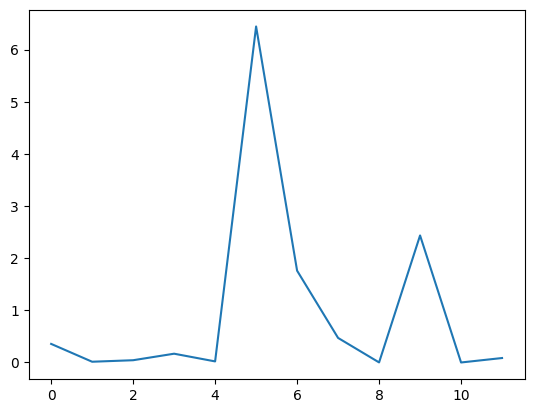

In [21]:
import matplotlib.pyplot as plt
print(steps)
plt.plot([loss.item() for loss in losses])

In [23]:
num_correct = 0
num_samples = len(test_dataset)

model.eval()

with torch.no_grad():
    for name, label in test_dataset:
        hidden_state = model.init_hidden()
        for char in name:
            output, hidden_state = model(char, hidden_state)
        _, pred = torch.max(output, dim=1)
        num_correct += bool(pred == label)

print(f"Accuracy: {num_correct / num_samples * 100:.4f}%")

Accuracy: 72.2970%


In [24]:
label2lang = {label.item(): lang for lang, label in lang2label.items()}

def myrnn_predict(name):
    model.eval()
    tensor_name = name2tensor(name)
    with torch.no_grad():
        hidden_state = model.init_hidden()
        for char in tensor_name:
            output, hidden_state = model(char, hidden_state)
        _, pred = torch.max(output, dim=1)
    model.train()
    return label2lang[pred.item()]

In [26]:
myrnn_predict("Arun")

'Russian'

In [28]:
myrnn_predict("Trump")

'English'

In [32]:
class GRUModel(nn.Module):
    def __init__(self, num_layers, hidden_size):
        super(GRUModel, self).__init__()
        self.num_layers = num_layers
        self.hidden_size = hidden_size
        self.gru = nn.GRU(
            input_size=num_letters,
            hidden_size=hidden_size,
            num_layers=num_layers,
        )
        self.fc = nn.Linear(hidden_size, num_langs)

    def forward(self, x):
        hidden_state = self.init_hidden()
        output, hidden_state = self.gru(x, hidden_state)
        output = self.fc(output[-1])
        return output

    def init_hidden(self):
        return torch.zeros(self.num_layers, 1, self.hidden_size)

In [33]:
model = GRUModel(num_layers=2, hidden_size=hidden_size)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [34]:
for epoch in range(num_epochs):
    random.shuffle(train_dataset)
    for i, (name, label) in enumerate(train_dataset):
        output = model(name)
        loss = criterion(output, label)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (i + 1) % print_interval == 0:
            print(
                f"Epoch [{epoch + 1}/{num_epochs}], "
                f"Step [{i + 1}/{len(train_dataset)}], "
                f"Loss: {loss.item():.4f}"
            )

Epoch [1/2], Step [3000/18063], Loss: 0.1425
Epoch [1/2], Step [6000/18063], Loss: 0.0926
Epoch [1/2], Step [9000/18063], Loss: 0.0040
Epoch [1/2], Step [12000/18063], Loss: 0.4896
Epoch [1/2], Step [15000/18063], Loss: 0.0540
Epoch [1/2], Step [18000/18063], Loss: 0.0038
Epoch [2/2], Step [3000/18063], Loss: 0.0158
Epoch [2/2], Step [6000/18063], Loss: 0.6994
Epoch [2/2], Step [9000/18063], Loss: 3.6107
Epoch [2/2], Step [12000/18063], Loss: 0.0001
Epoch [2/2], Step [15000/18063], Loss: 0.0001
Epoch [2/2], Step [18000/18063], Loss: 0.0707


In [35]:
num_correct = 0

model.eval()

with torch.no_grad():
    for name, label in test_dataset:
        output = model(name)
        _, pred = torch.max(output, dim=1)
        num_correct += bool(pred == label)

print(f"Accuracy: {num_correct / num_samples * 100:.4f}%")

Accuracy: 81.6642%


In [36]:
def pytorch_predict(name):
    model.eval()
    tensor_name = name2tensor(name)
    with torch.no_grad():
        output = model(tensor_name)
        _, pred = torch.max(output, dim=1)
    model.train()
    return label2lang[pred.item()]

In [40]:
pytorch_predict("Kim")


'Korean'

In [38]:
pytorch_predict("Arun")

'English'

In [39]:
pytorch_predict("Trump")

'English'